In [ ]:
#importing the dataset into python
import pandas as pd

url = "https://vincentarelbundock.github.io/Rdatasets/csv/wooldridge/wage1.csv"

df = pd.read_csv(url)

df.head()

,rownames,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
0,1,3.10,11,2,0,0,1,0,2,1,...,0,0,0,0,0,0,0,1.131402,4,0
1,2,3.24,12,22,2,0,1,1,3,1,...,0,0,1,0,0,0,1,1.175573,484,4
2,3,3.00,11,2,0,0,0,0,2,0,...,0,1,0,0,0,0,0,1.098612,4,0
3,4,6.00,8,44,28,0,0,1,0,1,...,0,0,0,0,0,1,0,1.791759,1936,784
4,5,5.30,12,7,2,0,0,1,1,0,...,0,0,0,0,0,0,0,1.667707,49,4


Descriptive statistics

In [ ]:
# Display basic information about the DataFrame (columns, non-null values, dtypes)
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 25 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  526 non-null    int64  
 1   wage      526 non-null    float64
 2   educ      526 non-null    int64  
 3   exper     526 non-null    int64  
 4   tenure    526 non-null    int64  
 5   nonwhite  526 non-null    int64  
 6   female    526 non-null    int64  
 7   married   526 non-null    int64  
 8   numdep    526 non-null    int64  
 9   smsa      526 non-null    int64  
 10  northcen  526 non-null    int64  
 11  south     526 non-null    int64  
 12  west      526 non-null    int64  
 13  construc  526 non-null    int64  
 14  ndurman   526 non-null    int64  
 15  trcommpu  526 non-null    int64  
 16  trade     526 non-null    int64  
 17  services  526 non-null    int64  
 18  profserv  526 non-null    int64  
 19  profocc   526 non-null    int64  
 20  clerocc   526 non-null    int64 

None

In [ ]:
#descriptive statistics for the variables used in the full model
display(df[['wage', 'educ', 'exper', 'tenure', 'female', 'married', 'numdep']].describe())

,wage,educ,exper,tenure,female,married,numdep
count,526.000000,526.000000,526.00000,526.000000,526.000000,526.000000,526.000000
mean,5.896103,12.562738,17.01711,5.104563,0.479087,0.608365,1.043726
std,3.693086,2.769022,13.57216,7.224462,0.500038,0.488580,1.261891
min,0.530000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000
25%,3.330000,12.000000,5.00000,0.000000,0.000000,0.000000,0.000000
50%,4.650000,12.000000,13.50000,2.000000,0.000000,1.000000,1.000000
75%,6.880000,14.000000,26.00000,7.000000,1.000000,1.000000,2.000000
max,24.980000,18.000000,51.00000,44.000000,1.000000,1.000000,6.000000


In [ ]:
# Display the shape of the DataFrame (number of rows and columns)
print(f"The DataFrame has {df.shape[0]} rows and {df.shape[1]} columns.")

The DataFrame has 526 rows and 25 columns.


In [ ]:
#checking to see if any variables have missing values
df.isna().sum()

,0
rownames,0
wage,0
educ,0
exper,0
tenure,0
nonwhite,0
female,0
married,0
numdep,0
smsa,0


In [ ]:
#seeing the number of males vs females in the dataset
df['female'].value_counts()


,count
female,
0,274
1,252


In [ ]:
#seeing the number of married vs not married individuals in the dataset
df['married'].value_counts()

,count
married,
1,320
0,206


In [ ]:
#amount of individuals for different years of education
#highest seems to be 12
df['educ'].value_counts().sort_index()

,count
educ,
0,2
2,1
3,1
4,3
5,1
6,6
7,4
8,22
9,17


In [ ]:
#variance covariance matrix for education, experience and tenure
df[['educ', 'exper', 'tenure']].corr()

,educ,exper,tenure
educ,1.000000,-0.299542,-0.056173
exper,-0.299542,1.000000,0.499291
tenure,-0.056173,0.499291,1.000000


In [ ]:
#variance covariance matrix for experience and wages
df[['exper', 'wage']].corr()

,exper,wage
exper,1.000000,0.112903
wage,0.112903,1.000000


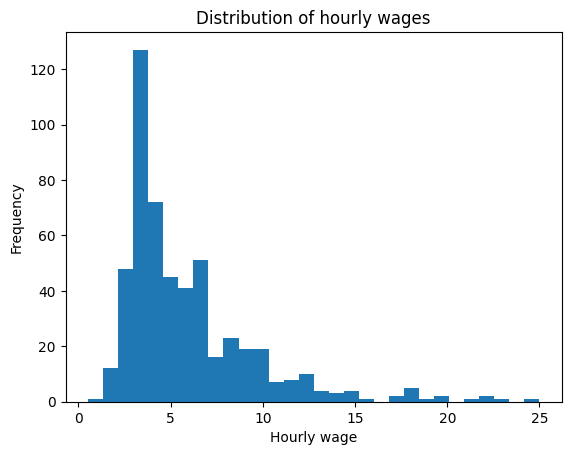

In [ ]:
#histogram to show the distribution of hourly wages amongst the 526 observations
import matplotlib.pyplot as plt

plt.hist(df['wage'], bins=30)
plt.xlabel('Hourly wage')
plt.ylabel('Frequency')
plt.title('Distribution of hourly wages')
plt.show()

In [ ]:
#number of, mean, and median wages for each year of education
#average wages tend to be higher for higher levels of education
df.groupby('educ')['wage'].agg(['count', 'mean', 'median'])

,count,mean,median
educ,,,
0,2,3.530000,3.530
2,1,3.750000,3.750
3,1,2.920000,2.920
4,3,3.170000,3.000
5,1,2.900000,2.900
6,6,3.985000,3.855
7,4,4.387500,4.150
8,22,5.038182,3.775
9,17,3.275882,3.000


In [ ]:
#variance covariance matrix for education and wages
df[['educ', 'wage']].corr()

,educ,wage
educ,1.000000,0.405903
wage,0.405903,1.000000


## OLS Regressions

In [ ]:
import statsmodels.formula.api as smf

# Regression 1: wage on education and a constant
model1 = smf.ols('wage ~ educ', data=df).fit()
print('--- Regression 1: wage ~ educ ---')
print(model1.summary())

--- Regression 1: wage ~ educ ---
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     103.4
Date:                Mon, 31 Aug 2026   Prob (F-statistic):           2.78e-22
Time:                        21:07:44   Log-Likelihood:                -1385.7
No. Observations:                 526   AIC:                             2775.
Df Residuals:                     524   BIC:                             2784.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9

In [ ]:
# Regression 2: wage on education, experience, and a constant
model2 = smf.ols('wage ~ educ + exper', data=df).fit()
print('\n--- Regression 2: wage ~ educ + exper ---')
print(model2.summary())


--- Regression 2: wage ~ educ + exper ---
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.225
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     75.99
Date:                Mon, 31 Aug 2026   Prob (F-statistic):           1.07e-29
Time:                        21:07:51   Log-Likelihood:                -1366.0
No. Observations:                 526   AIC:                             2738.
Df Residuals:                     523   BIC:                             2751.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept

In [ ]:
# Regression 3: wage on education, experience, tenure, gender, marital status, and number of dependents
model3 = smf.ols('wage ~ educ + exper + tenure + female + married + numdep', data=df).fit()
print('\n--- Regression 3: wage ~ educ + exper + tenure + female + married + numdep ---')
print(model3.summary())


--- Regression 3: wage ~ educ + exper + tenure + female + married + numdep ---
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.370
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     50.87
Date:                Mon, 31 Aug 2026   Prob (F-statistic):           3.50e-49
Time:                        21:07:57   Log-Likelihood:                -1311.4
No. Observations:                 526   AIC:                             2637.
Df Residuals:                     519   BIC:                             2667.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

Breusch-Pagan test for heteroskedasticity

In [ ]:
import statsmodels.stats.api as sms

# Breusch-Pagan test for model 1
name = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
bp_test_model1 = sms.het_breuschpagan(model1.resid, model1.model.exog)
print('\n--- Breusch-Pagan Test for Model 1 ---')
print(dict(zip(name, bp_test_model1)))

# Breusch-Pagan test for model 2
bp_test_model2 = sms.het_breuschpagan(model2.resid, model2.model.exog)
print('\n--- Breusch-Pagan Test for Model 2 ---')
print(dict(zip(name, bp_test_model2)))

# Breusch-Pagan test for model 3
bp_test_model3 = sms.het_breuschpagan(model3.resid, model3.model.exog)
print('\n--- Breusch-Pagan Test for Model 3 ---')
print(dict(zip(name, bp_test_model3)))



--- Breusch-Pagan Test for Model 1 ---
{'Lagrange multiplier statistic': np.float64(15.305628705020107), 'p-value': np.float64(9.144363288378174e-05), 'f-value': np.float64(15.70440148203251), 'f p-value': np.float64(8.431687368335582e-05)}

--- Breusch-Pagan Test for Model 2 ---
{'Lagrange multiplier statistic': np.float64(31.847282579768454), 'p-value': np.float64(1.2146480463878308e-07), 'f-value': np.float64(16.853219867102748), 'f p-value': np.float64(8.071022441835995e-08)}

--- Breusch-Pagan Test for Model 3 ---
{'Lagrange multiplier statistic': np.float64(43.41522476314023), 'p-value': np.float64(9.652906758605745e-08), 'f-value': np.float64(7.781880272058761), 'f p-value': np.float64(4.944586201478318e-08)}


## OLS Regressions with Heteroskedasticity-Robust Standard Errors

In [ ]:
import statsmodels.formula.api as smf

# Regression 1 (New): wage on education and a constant with HC1 robust standard errors
model1_hc = smf.ols('wage ~ educ', data=df).fit(cov_type='HC1')
print('--- New Regression 1 (HC1 Robust SEs): wage ~ educ ---')
print(model1_hc.summary())

--- New Regression 1 (HC1 Robust SEs): wage ~ educ ---
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     78.09
Date:                Mon, 31 Aug 2026   Prob (F-statistic):           1.49e-17
Time:                        21:08:06   Log-Likelihood:                -1385.7
No. Observations:                 526   AIC:                             2775.
Df Residuals:                     524   BIC:                             2784.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

In [ ]:
# Regression 2 (New): wage on education, experience, and a constant with HC1 robust standard errors
model2_hc = smf.ols('wage ~ educ + exper', data=df).fit(cov_type='HC1')
print('\n--- New Regression 2 (HC1 Robust SEs): wage ~ educ + exper ---')
print(model2_hc.summary())


--- New Regression 2 (HC1 Robust SEs): wage ~ educ + exper ---
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.225
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     50.32
Date:                Mon, 31 Aug 2026   Prob (F-statistic):           1.03e-20
Time:                        21:08:09   Log-Likelihood:                -1366.0
No. Observations:                 526   AIC:                             2738.
Df Residuals:                     523   BIC:                             2751.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

In [ ]:
# Regression 3 (New): wage on education, experience, tenure, gender, marital status, and number of dependents with HC1 robust standard errors
model3_hc = smf.ols('wage ~ educ + exper + tenure + female + married + numdep', data=df).fit(cov_type='HC1')
print('\n--- New Regression 3 (HC1 Robust SEs): wage ~ educ + exper + tenure + female + married + numdep ---\n')
print(model3_hc.summary())


--- New Regression 3 (HC1 Robust SEs): wage ~ educ + exper + tenure + female + married + numdep ---

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.370
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     31.92
Date:                Mon, 31 Aug 2026   Prob (F-statistic):           1.01e-32
Time:                        21:08:11   Log-Likelihood:                -1311.4
No. Observations:                 526   AIC:                             2637.
Df Residuals:                     519   BIC:                             2667.
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------

VIF test in regression 3 for multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a DataFrame to store VIF values
vif_data = pd.DataFrame()
vif_data['feature'] = model3_hc.model.exog_names[1:] # Exclude the constant
vif_data['VIF'] = [variance_inflation_factor(model3_hc.model.exog, i) for i in range(1, model3_hc.model.exog.shape[1])]

print('--- VIF for Model 3 (educ + exper + tenure + female + married + numdep) ---')
display(vif_data.sort_values(by='VIF', ascending=False))

--- VIF for Model 3 (educ + exper + tenure + female + married + numdep) ---


,feature,VIF
1,exper,1.670458
2,tenure,1.407412
0,educ,1.250892
4,married,1.249400
5,numdep,1.132517
3,female,1.073712


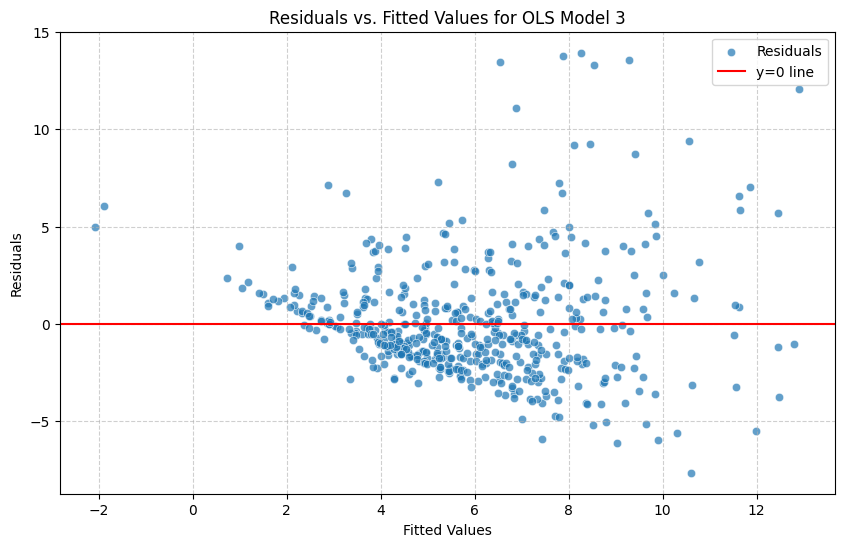

In [ ]:
#Residuals vs. Fitted Values Plot for OLS Model 3 (Full Model)

import matplotlib.pyplot as plt
import seaborn as sns

# Get residuals and fitted values from model3_hc
residuals = model3_hc.resid
fitted_values = model3_hc.fittedvalues

# Create the plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.7, label='Residuals')
plt.axhline(y=0, color='r', linestyle='-', label='y=0 line')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values for OLS Model 3')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()